# 🎓 TunisChomPredict — Analysis and Prediction of Regional Employability
**Student:** Achref Allegui | **Group:** GR5 DS | **Date:** March 2026

---
### Project Objective
Build a Machine Learning pipeline to:
1. **Predict** the unemployment rate for upcoming quarters (Regression)
2. **Classify** graduate profiles into risk categories: Low / Moderate / Critical
3. **Analyze** which factor matters more — Geography or Gender
4. **Compute** the ChomScore: a personalized employability index per governorate

## 📦 Section 1 — Install & Import Libraries

In [ ]:
# Install any missing libraries (Colab usually has most of these)
!pip install lightgbm xgboost scikit-learn matplotlib seaborn plotly pandas numpy -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 📂 Section 2 — Load Dataset

In [ ]:
# Upload the CSV file when running on Colab
# from google.colab import files
# uploaded = files.upload()

# OR load directly if on Drive:
# df = pd.read_csv('/content/drive/MyDrive/tunisia_unemployment_4datasets_augmented.csv')

# Load the dataset
df = pd.read_csv('/content/tunisia_unemployment_4datasets_augmented.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Dataset shape: (3298, 19)
Columns: ['year', 'quarter', 'gouvernorat', 'gender', 'education', 'metric', 'unit', 'value', 'source', 'is_post_revolution', 'is_covid_period', 'is_recent', 'gender_encoded', 'education_encoded', 'is_national', 'metric_encoded', 'is_augmented', 'quarter_num', 'value_normalized']


,year,quarter,gouvernorat,gender,education,metric,unit,value,source,is_post_revolution,is_covid_period,is_recent,gender_encoded,education_encoded,is_national,metric_encoded,is_augmented,quarter_num,value_normalized
0,2007,NaN,Tunis,total,all,count_thousands,count,44.0,regional_annual,0,0,0,0,0,0,0,0,0,0.0542
1,2008,NaN,Tunis,total,all,count_thousands,count,48.0,regional_annual,0,0,0,0,0,0,0,0,0,0.0593
2,2009,NaN,Tunis,total,all,count_thousands,count,40.0,regional_annual,0,0,0,0,0,0,0,0,0,0.0491
3,2010,NaN,Tunis,total,all,count_thousands,count,53.0,regional_annual,0,0,0,0,0,0,0,0,0,0.0657
4,2012,NaN,Tunis,total,all,count_thousands,count,82.0,regional_annual,1,0,0,0,0,0,0,0,0,0.1028
5,2013,NaN,Tunis,total,all,count_thousands,count,73.0,regional_annual,1,0,0,0,0,0,0,0,0,0.0913
6,2014,NaN,Tunis,total,all,count_thousands,count,57.0,regional_annual,1,0,0,0,0,0,0,0,0,0.0708
7,2015,NaN,Tunis,total,all,count_thousands,count,82.0,regional_annual,1,0,0,0,0,0,0,0,0,0.1028
8,2016,NaN,Tunis,total,all,count_thousands,count,90.0,regional_annual,1,0,0,0,0,0,0,0,0,0.1130
9,2007,NaN,Sfax,total,all,count_thousands,count,31.0,regional_annual,0,0,0,0,0,0,0,0,0,0.0376


## 🔍 Section 3 — Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target variable (value) statistics ===')
print(df['value'].describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3298 entries, 0 to 3297
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                3298 non-null   int64  
 1   quarter             1546 non-null   object 
 2   gouvernorat         3298 non-null   object 
 3   gender              3298 non-null   object 
 4   education           3298 non-null   object 
 5   metric              3298 non-null   object 
 6   unit                3298 non-null   object 
 7   value               3298 non-null   float64
 8   source              3298 non-null   object 
 9   is_post_revolution  3298 non-null   int64  
 10  is_covid_period     3298 non-null   int64  
 11  is_recent           3298 non-null   int64  
 12  gender_encoded      3298 non-null   int64  
 13  education_encoded   3298 non-null   int64  
 14  is_national         3298 non-null   int64  
 15  metric_encoded      3298 non-null 

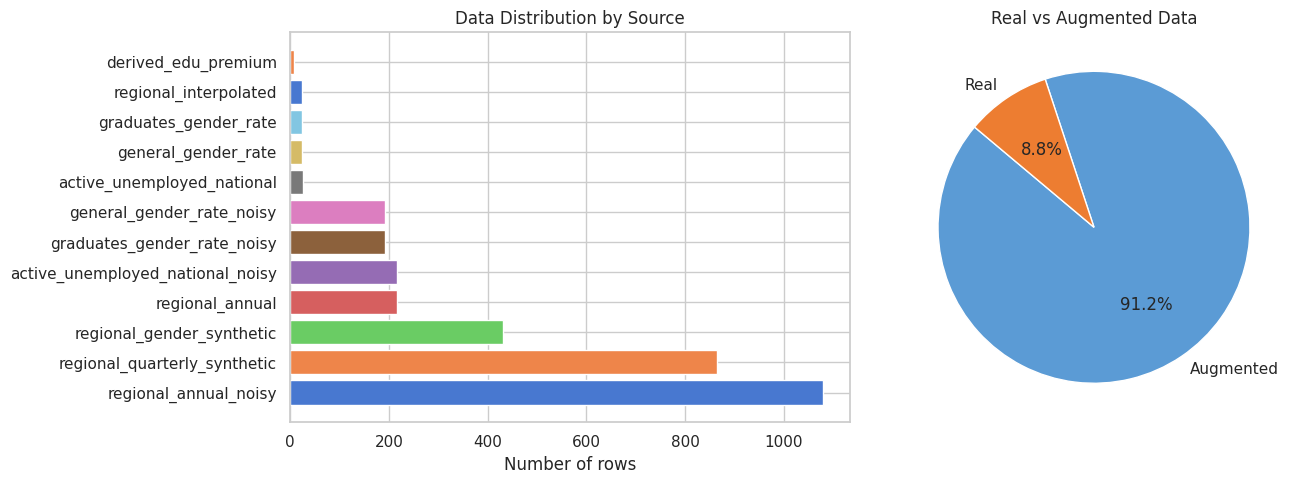

In [ ]:
# Distribution of sources (real vs augmented)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_counts = df['source'].value_counts()
axes[0].barh(source_counts.index, source_counts.values, color=sns.color_palette('muted', len(source_counts)))
axes[0].set_title('Data Distribution by Source')
axes[0].set_xlabel('Number of rows')

aug_counts = df['is_augmented'].value_counts()
axes[1].pie(aug_counts.values, labels=['Augmented', 'Real'], autopct='%1.1f%%',
            colors=['#5B9BD5', '#ED7D31'], startangle=140)
axes[1].set_title('Real vs Augmented Data')

plt.tight_layout()
plt.savefig('fig_data_sources.png', dpi=150, bbox_inches='tight')
plt.show()

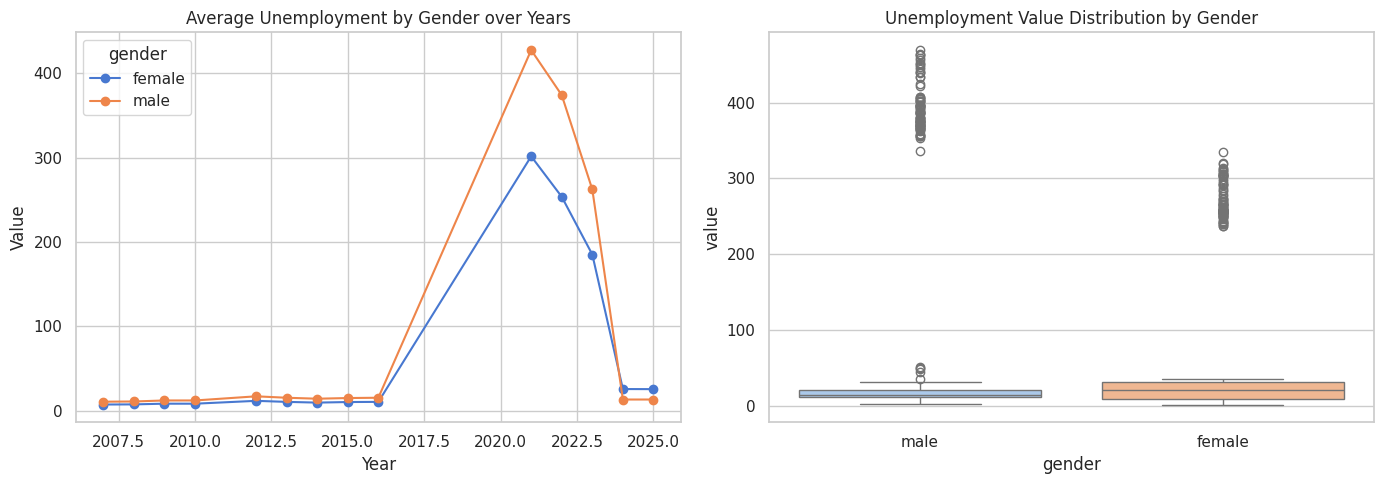

In [ ]:
# Unemployment distribution by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_gender = df[df['gender'].isin(['male','female'])]
df_gender.groupby(['year','gender'])['value'].mean().unstack().plot(ax=axes[0], marker='o')
axes[0].set_title('Average Unemployment by Gender over Years')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Value')

sns.boxplot(data=df_gender, x='gender', y='value', palette='pastel', ax=axes[1])
axes[1].set_title('Unemployment Value Distribution by Gender')

plt.tight_layout()
plt.savefig('fig_gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

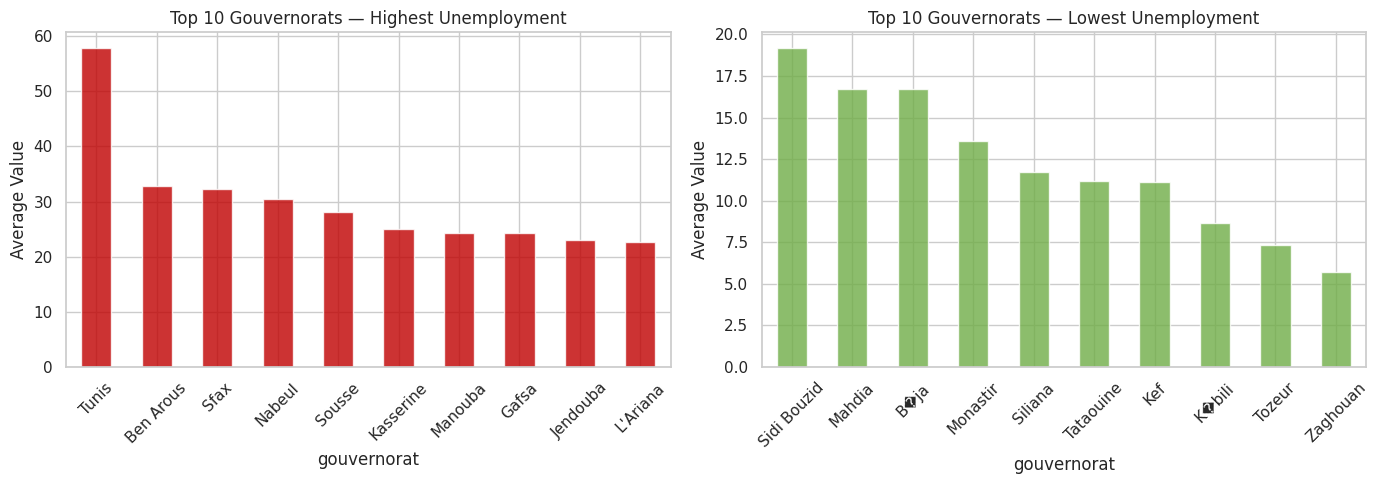

In [ ]:
# Top & Bottom gouvernorats by unemployment
df_regional = df[df['gouvernorat'] != 'national'].copy()
gov_avg = df_regional.groupby('gouvernorat')['value'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gov_avg.head(10).plot(kind='bar', ax=axes[0], color='#C00000', alpha=0.8)
axes[0].set_title('Top 10 Gouvernorats — Highest Unemployment')
axes[0].set_ylabel('Average Value'); axes[0].tick_params(axis='x', rotation=45)

gov_avg.tail(10).plot(kind='bar', ax=axes[1], color='#70AD47', alpha=0.8)
axes[1].set_title('Top 10 Gouvernorats — Lowest Unemployment')
axes[1].set_ylabel('Average Value'); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

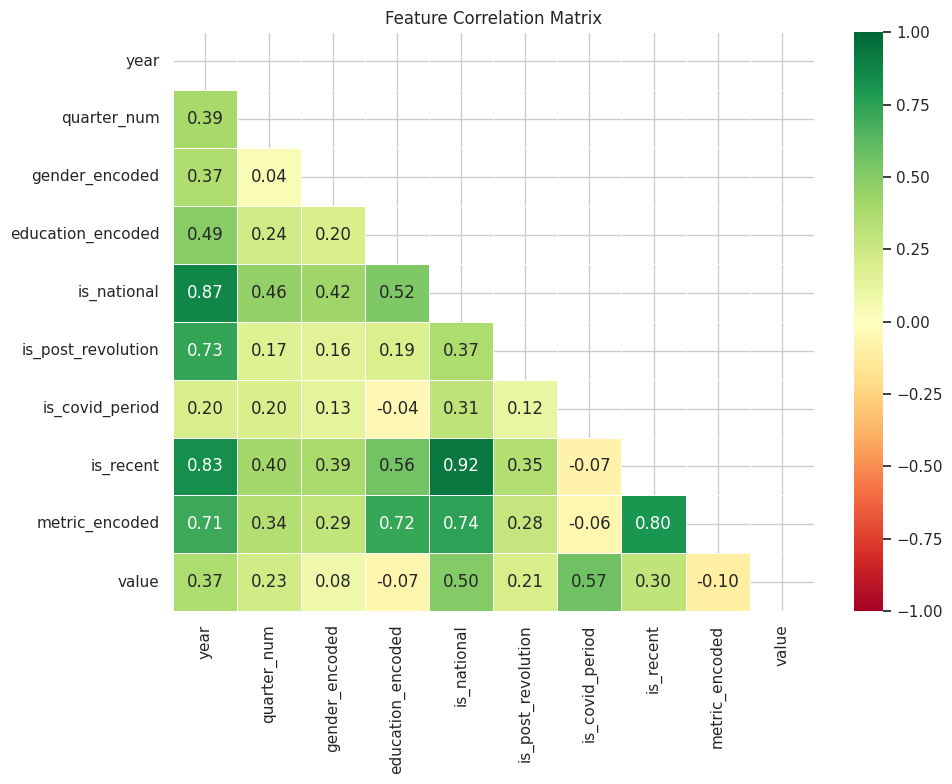

In [ ]:
# Correlation heatmap
numeric_cols = ['year', 'quarter_num', 'gender_encoded', 'education_encoded',
                'is_national', 'is_post_revolution', 'is_covid_period',
                'is_recent', 'metric_encoded', 'value']

corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

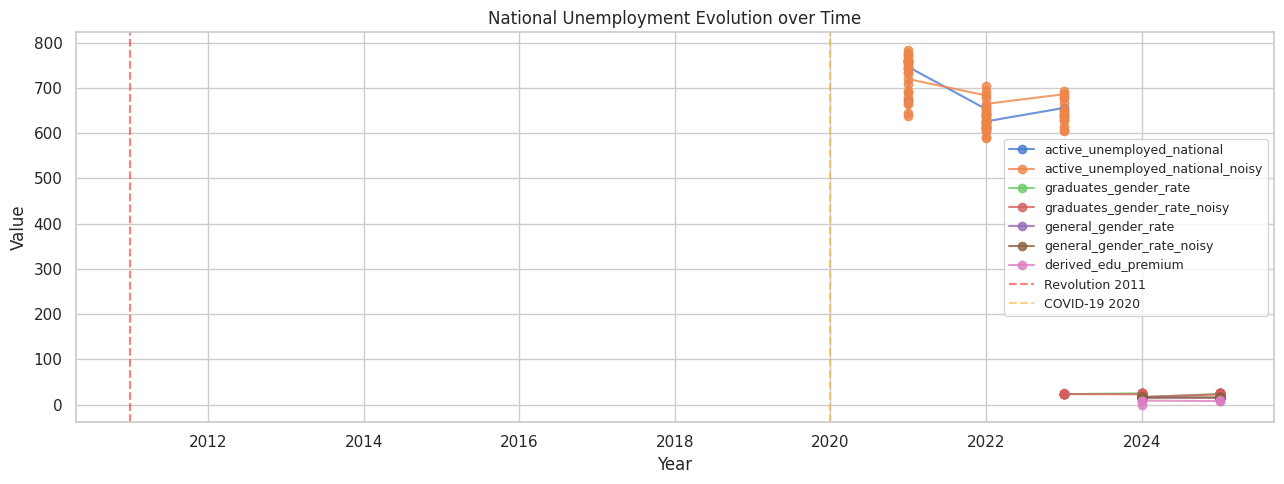

In [ ]:
# Temporal trend — national unemployment evolution
df_national = df[df['gouvernorat'] == 'national'].copy()
df_national_total = df_national[df_national['gender'] == 'total'].sort_values('year')

plt.figure(figsize=(13, 5))
for src in df_national_total['source'].unique():
    sub = df_national_total[df_national_total['source'] == src]
    plt.plot(sub['year'], sub['value'], marker='o', label=src, alpha=0.8)

plt.axvline(x=2011, color='red', linestyle='--', alpha=0.5, label='Revolution 2011')
plt.axvline(x=2020, color='orange', linestyle='--', alpha=0.5, label='COVID-19 2020')
plt.title('National Unemployment Evolution over Time')
plt.xlabel('Year'); plt.ylabel('Value'); plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_temporal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 🛠️ Section 4 — Data Preprocessing & Feature Engineering

In [ ]:
# We work only on real data + interpolated (no noisy augmentation) for clean ML
# This avoids data leakage from augmented copies in test set

REAL_SOURCES = [
    'regional_annual', 'graduates_gender_rate', 'general_gender_rate',
    'active_unemployed_national', 'regional_interpolated',
    'regional_gender_synthetic', 'regional_quarterly_synthetic', 'derived_edu_premium'
]

df_ml = df[df['source'].isin(REAL_SOURCES)].copy()
print(f'ML dataset shape (no leaky augmentation): {df_ml.shape}')

# Drop rows where value is null
df_ml = df_ml.dropna(subset=['value'])

# Fill nulls
df_ml['quarter_num'] = df_ml['quarter_num'].fillna(0).astype(int)
df_ml['gouvernorat'] = df_ml['gouvernorat'].fillna('unknown')

# Encode gouvernorat
le_gov = LabelEncoder()
df_ml['gouvernorat_encoded'] = le_gov.fit_transform(df_ml['gouvernorat'])

print('Gouvernorat classes:', le_gov.classes_)
print(df_ml[['gouvernorat','gouvernorat_encoded']].drop_duplicates().head(10))

ML dataset shape (no leaky augmentation): (1618, 19)
Gouvernorat classes: ['Ben Arous' 'Bizerte' 'B�ja' 'Gab�s' 'Gafsa' 'Jendouba' 'Kairouan'
 'Kasserine' 'Kef' 'K�bili' "L'Ariana" 'Mahdia' 'Manouba' 'Medenine'
 'Monastir' 'Nabeul' 'Sfax' 'Sidi Bouzid' 'Siliana' 'Sousse' 'Tataouine'
 'Tozeur' 'Tunis' 'Zaghouan' 'national']
   gouvernorat  gouvernorat_encoded
0        Tunis                   22
9         Sfax                   16
18   Ben Arous                    0
27      Nabeul                   15
36    Jendouba                    5
45      Sousse                   19
54     Bizerte                    1
63    L'Ariana                   10
72   Kasserine                    7
81     Manouba                   12


=== ChomScore by Gouvernorat (Top 10) ===
gouvernorat
Zaghouan       100.0
Tozeur          99.0
K�bili          98.2
Tataouine       96.7
Kef             96.7
Siliana         96.3
Monastir        95.2
B�ja            93.2
Mahdia          93.2
Sidi Bouzid     91.7
Name: value, dtype: float64


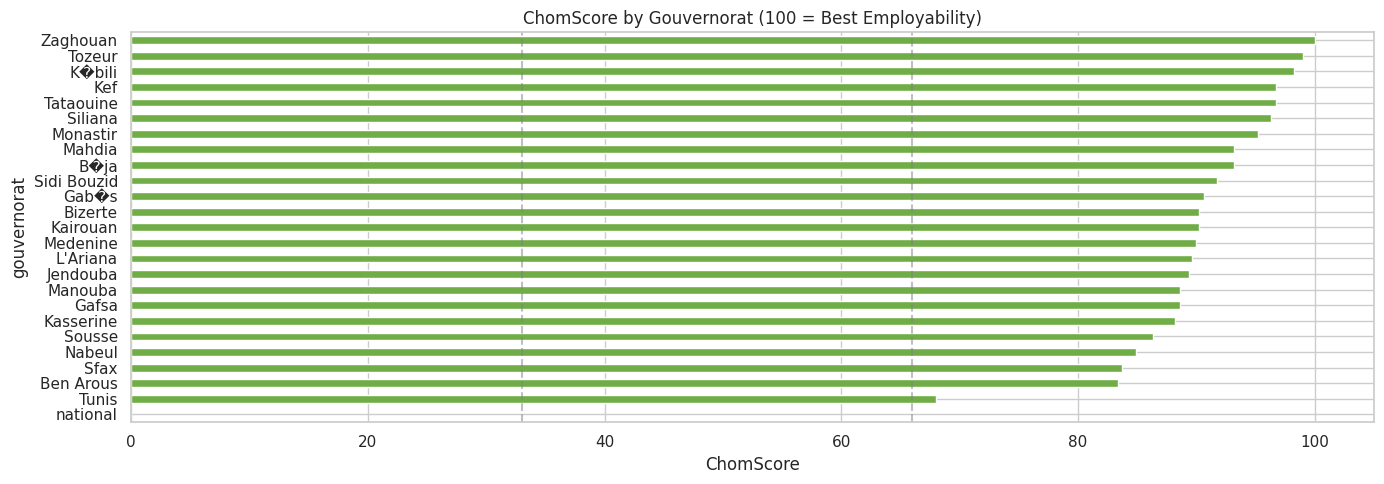

In [ ]:
# ============================================================
# ChomScore — Personalized Employability Index
# Score = normalized inverse of unemployment value per governorate
# Higher ChomScore = Better employability
# ============================================================

gov_mean = df_ml.groupby('gouvernorat')['value'].mean()
gov_max  = gov_mean.max()
gov_min  = gov_mean.min()

# Invert: higher unemployment → lower score
chomscore_map = ((gov_max - gov_mean) / (gov_max - gov_min + 1e-9) * 100).round(1)
df_ml['chomscore'] = df_ml['gouvernorat'].map(chomscore_map)

print('=== ChomScore by Gouvernorat (Top 10) ===')
print(chomscore_map.sort_values(ascending=False).head(10))

# Visualize ChomScore
plt.figure(figsize=(14, 5))
chomscore_map.sort_values().plot(kind='barh',
    color=[('#C00000' if v < 33 else '#FFC000' if v < 66 else '#70AD47') for v in chomscore_map.sort_values()])
plt.axvline(x=33, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=66, color='gray', linestyle='--', alpha=0.5)
plt.title('ChomScore by Gouvernorat (100 = Best Employability)')
plt.xlabel('ChomScore')
plt.tight_layout()
plt.savefig('fig_chomscore.png', dpi=150, bbox_inches='tight')
plt.show()

Thresholds → Low: ≤12.9 | Moderate: 12.9–23.2 | Critical: >23.2

Risk distribution:
risk_label
Critical    550
Low         539
Moderate    529
Name: count, dtype: int64


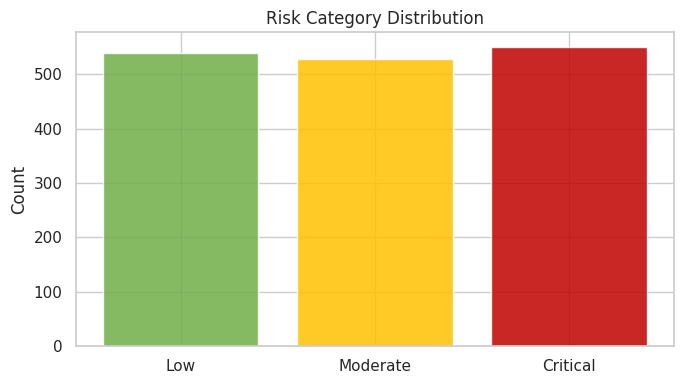

In [ ]:
# ============================================================
# Create Risk Classification Target
# Low < 33rd percentile | Moderate = 33-66th | Critical > 66th
# ============================================================

p33 = df_ml['value'].quantile(0.33)
p66 = df_ml['value'].quantile(0.66)

def classify_risk(v):
    if v <= p33: return 0   # Low
    elif v <= p66: return 1  # Moderate
    else: return 2           # Critical

df_ml['risk_label'] = df_ml['value'].apply(classify_risk)
label_names = {0: 'Low', 1: 'Moderate', 2: 'Critical'}

print(f'Thresholds → Low: ≤{p33:.1f} | Moderate: {p33:.1f}–{p66:.1f} | Critical: >{p66:.1f}')
print('\nRisk distribution:')
print(df_ml['risk_label'].value_counts().rename(label_names))

# Plot
risk_counts = df_ml['risk_label'].value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar(['Low','Moderate','Critical'], risk_counts.values,
        color=['#70AD47','#FFC000','#C00000'], alpha=0.85)
plt.title('Risk Category Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fig_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Final feature set
FEATURES = [
    'year', 'quarter_num', 'gender_encoded', 'education_encoded',
    'is_national', 'is_post_revolution', 'is_covid_period',
    'is_recent', 'metric_encoded', 'gouvernorat_encoded', 'chomscore'
]

X = df_ml[FEATURES].copy()
y_reg = df_ml['value']          # Regression target
y_clf = df_ml['risk_label']     # Classification target

print(f'Features shape: {X.shape}')
print(f'Regression target range: {y_reg.min():.1f} → {y_reg.max():.1f}')
print(f'Classification target: {sorted(y_clf.unique())} → {[label_names[i] for i in sorted(y_clf.unique())]}')

Features shape: (1618, 11)
Regression target range: 0.2 → 762.7
Classification target: [np.int64(0), np.int64(1), np.int64(2)] → ['Low', 'Moderate', 'Critical']


In [ ]:
# Train/test split — stratified for classification
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: (1294, 11) | Test: (324, 11)


## 📈 Section 5 — Regression: Predict Unemployment Value

In [ ]:
# ============================================================
# REGRESSION MODELS
# ============================================================

reg_models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    'XGBoost':            xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                           max_depth=5, random_state=42, verbosity=0),
    'LightGBM':           lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                            max_depth=5, random_state=42, verbose=-1)
}

reg_results = {}

for name, model in reg_models.items():
    if 'Regression' in name:
        model.fit(X_train_sc, y_train_reg)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train_reg)
        preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2   = r2_score(y_test_reg, preds)
    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f'{name:20s} → MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')

reg_df = pd.DataFrame(reg_results).T
print('\nBest Model:', reg_df['R²'].idxmax())

Linear Regression    → MAE=13.20  RMSE=44.19  R²=0.5742
Ridge Regression     → MAE=13.19  RMSE=44.20  R²=0.5739
Random Forest        → MAE=2.85  RMSE=7.44  R²=0.9879
XGBoost              → MAE=2.60  RMSE=5.02  R²=0.9945
LightGBM             → MAE=6.56  RMSE=21.76  R²=0.8968

Best Model: XGBoost


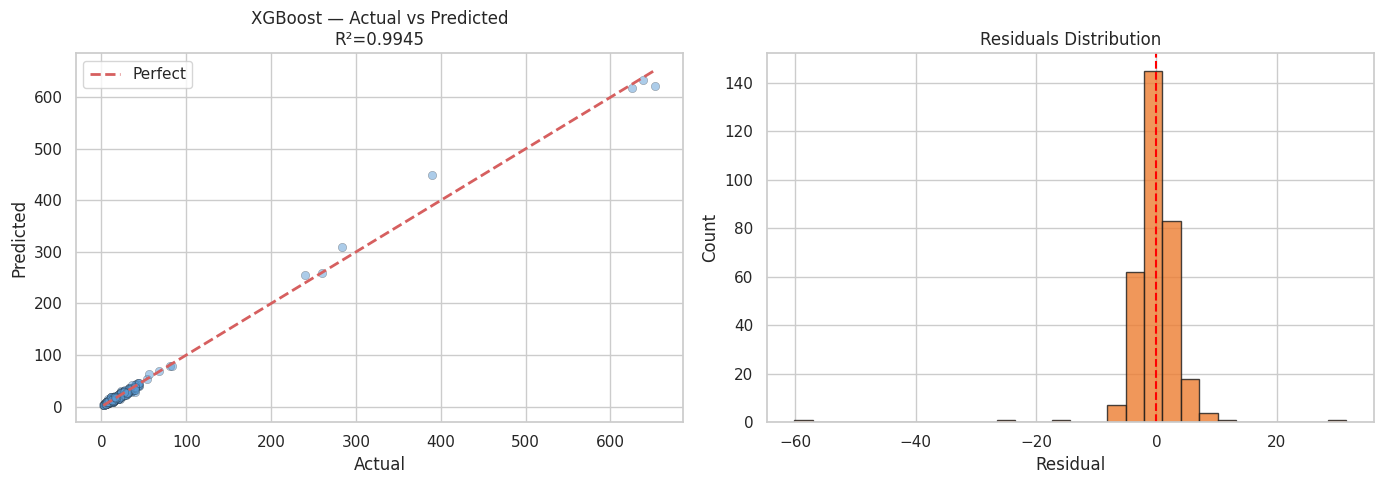

MAE  = 2.60
RMSE = 5.02
R²   = 0.9945


In [ ]:
# Best model: XGBoost — Predicted vs Actual plot
best_reg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                             max_depth=5, random_state=42, verbosity=0)
best_reg.fit(X_train, y_train_reg)
preds_best = best_reg.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_reg, preds_best, alpha=0.5, color='#5B9BD5', edgecolors='k', linewidths=0.3)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'XGBoost — Actual vs Predicted\nR²={r2_score(y_test_reg, preds_best):.4f}')
axes[0].legend()

# Residuals
residuals = y_test_reg - preds_best
axes[1].hist(residuals, bins=30, color='#ED7D31', edgecolor='k', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'MAE  = {mean_absolute_error(y_test_reg, preds_best):.2f}')
print(f'RMSE = {np.sqrt(mean_squared_error(y_test_reg, preds_best)):.2f}')
print(f'R²   = {r2_score(y_test_reg, preds_best):.4f}')

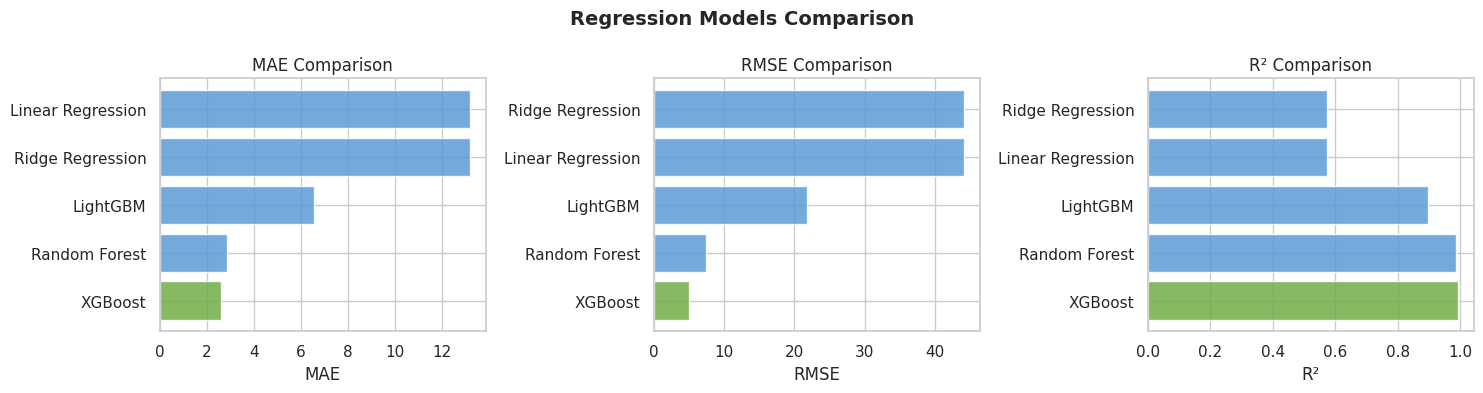

In [ ]:
# Regression model comparison bar chart
reg_df_plot = pd.DataFrame(reg_results).T.reset_index().rename(columns={'index':'Model'})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE','RMSE','R²']):
    ascending = metric != 'R²'
    sorted_df = reg_df_plot.sort_values(metric, ascending=ascending)
    colors = ['#70AD47' if i == 0 else '#5B9BD5' for i in range(len(sorted_df))]
    ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, alpha=0.85)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlabel(metric)

plt.suptitle('Regression Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🏷️ Section 6 — Classification: Predict Risk Category

In [ ]:
# ============================================================
# CLASSIFICATION MODELS
# ============================================================

clf_models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    'XGBoost':                xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                                max_depth=5, random_state=42,
                                                eval_metric='mlogloss', verbosity=0),
    'LightGBM':               lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                                  max_depth=5, random_state=42, verbose=-1)
}

clf_results = {}

for name, model in clf_models.items():
    if 'Logistic' in name:
        model.fit(X_train_sc, y_train_clf)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train_clf)
        preds = model.predict(X_test)

    acc = accuracy_score(y_test_clf, preds)
    clf_results[name] = {'Accuracy': acc, 'predictions': preds}
    print(f'{name:25s} → Accuracy = {acc:.4f}')

best_clf_name = max(clf_results, key=lambda k: clf_results[k]['Accuracy'])
print(f'\n🏆 Best Classifier: {best_clf_name} ({clf_results[best_clf_name]["Accuracy"]:.4f})')

Logistic Regression       → Accuracy = 0.7994
Decision Tree             → Accuracy = 0.8426
Random Forest             → Accuracy = 0.8519
Gradient Boosting         → Accuracy = 0.8735
XGBoost                   → Accuracy = 0.9105
LightGBM                  → Accuracy = 0.8827

🏆 Best Classifier: XGBoost (0.9105)


=== Classification Report ===
              precision    recall  f1-score   support

         Low       0.92      0.90      0.91       108
    Moderate       0.86      0.87      0.86       106
    Critical       0.95      0.96      0.96       110

    accuracy                           0.91       324
   macro avg       0.91      0.91      0.91       324
weighted avg       0.91      0.91      0.91       324



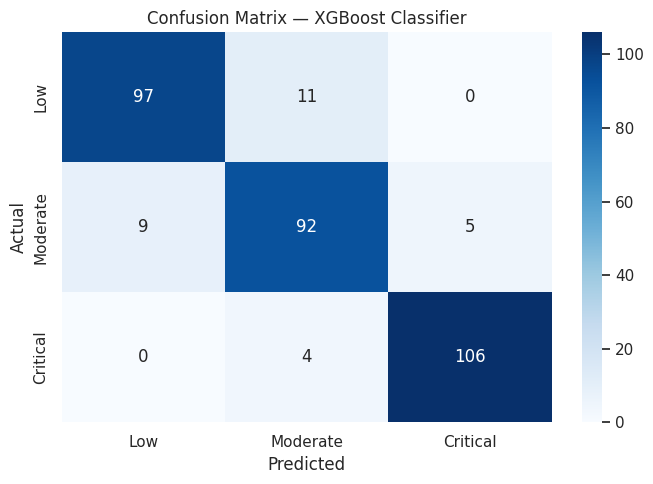

In [ ]:
# Detailed report + confusion matrix for best model
best_clf = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                               random_state=42, eval_metric='mlogloss', verbosity=0)
best_clf.fit(X_train, y_train_clf)
preds_clf = best_clf.predict(X_test)

print('=== Classification Report ===')
print(classification_report(y_test_clf, preds_clf,
                             target_names=['Low','Moderate','Critical']))

# Confusion Matrix
cm = confusion_matrix(y_test_clf, preds_clf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Moderate','Critical'],
            yticklabels=['Low','Moderate','Critical'])
plt.title('Confusion Matrix — XGBoost Classifier')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

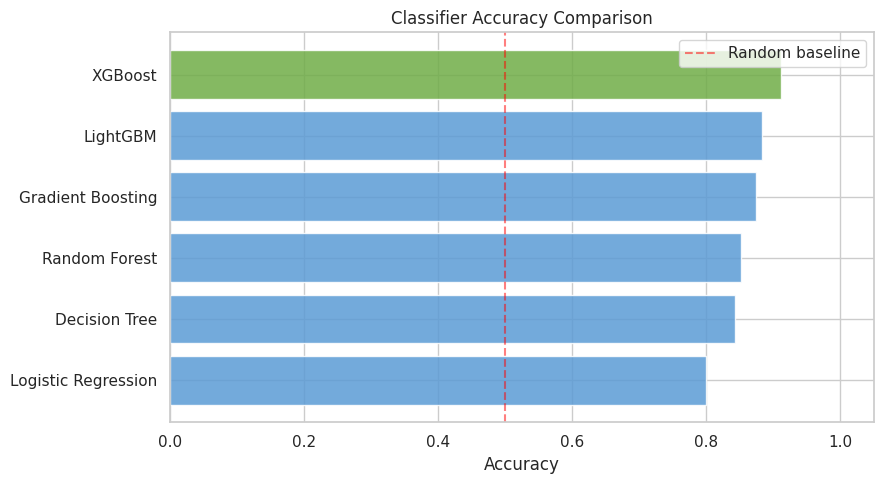

In [ ]:
# Classifier accuracy comparison
acc_df = pd.DataFrame({
    'Model': list(clf_results.keys()),
    'Accuracy': [clf_results[k]['Accuracy'] for k in clf_results]
}).sort_values('Accuracy', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#70AD47' if i == len(acc_df)-1 else '#5B9BD5' for i in range(len(acc_df))]
plt.barh(acc_df['Model'], acc_df['Accuracy'], color=colors, alpha=0.85)
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
plt.xlim(0, 1.05)
plt.title('Classifier Accuracy Comparison')
plt.xlabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('fig_clf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔑 Section 7 — Feature Importance: Geography vs Gender

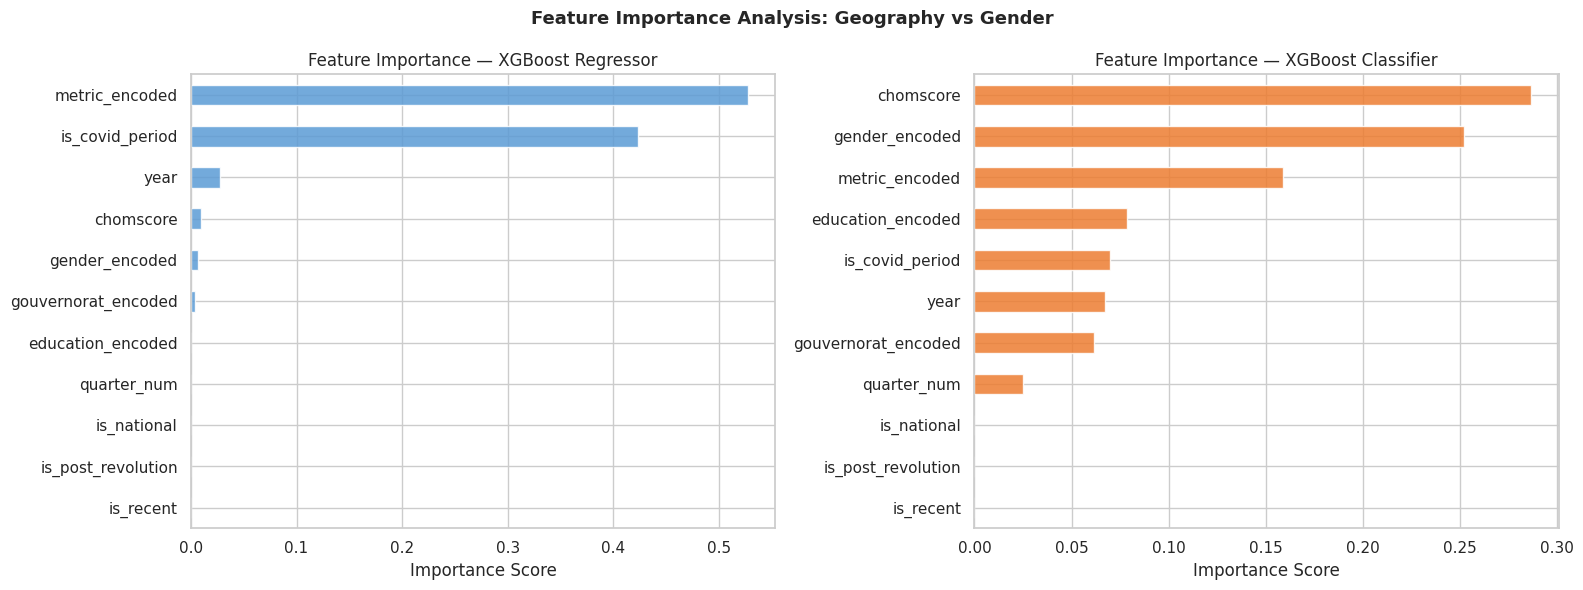


📊 RESEARCH ANSWER:
  → gouvernorat_encoded importance: 0.0618
  → gender_encoded importance:      0.2522
  → GENDER is the stronger predictor of unemployment risk!


In [ ]:
# ============================================================
# Feature Importance from XGBoost (both tasks)
# Research Question: Does Governorate matter more than Gender?
# ============================================================

fi_reg = pd.Series(best_reg.feature_importances_, index=FEATURES).sort_values(ascending=False)
fi_clf = pd.Series(best_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression importance
fi_reg.plot(kind='barh', ax=axes[0], color='#5B9BD5', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance — XGBoost Regressor')
axes[0].set_xlabel('Importance Score')

# Classification importance
fi_clf.plot(kind='barh', ax=axes[1], color='#ED7D31', alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_title('Feature Importance — XGBoost Classifier')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Analysis: Geography vs Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Answer the research question
gov_imp  = fi_clf.get('gouvernorat_encoded', 0)
gen_imp  = fi_clf.get('gender_encoded', 0)
print(f'\n📊 RESEARCH ANSWER:')
print(f'  → gouvernorat_encoded importance: {gov_imp:.4f}')
print(f'  → gender_encoded importance:      {gen_imp:.4f}')
winner = 'GEOGRAPHY (Gouvernorat)' if gov_imp > gen_imp else 'GENDER'
print(f'  → {winner} is the stronger predictor of unemployment risk!')

## 🔮 Section 8 — Forecasting 2026 Unemployment

In [ ]:
# ============================================================
# Predict 2026 Q1 & Q2 for each governorate
# ============================================================

governorates = [g for g in df_ml['gouvernorat'].unique() if g != 'national']
quarters_2026 = [1, 2]  # Q1, Q2

forecast_rows = []
for gov in governorates:
    gov_enc = le_gov.transform([gov])[0]
    cs      = chomscore_map.get(gov, 50)
    for q in quarters_2026:
        row = {
            'year': 2026, 'quarter_num': q,
            'gender_encoded': 0,       # total
            'education_encoded': 0,    # all
            'is_national': 0,
            'is_post_revolution': 1,
            'is_covid_period': 0,
            'is_recent': 1,
            'metric_encoded': 0,
            'gouvernorat_encoded': gov_enc,
            'chomscore': cs,
            'gouvernorat': gov,
            'quarter_label': f'Q{q}-2026'
        }
        forecast_rows.append(row)

df_forecast = pd.DataFrame(forecast_rows)
X_forecast  = df_forecast[FEATURES]

df_forecast['predicted_value']      = best_reg.predict(X_forecast).round(1)
df_forecast['predicted_risk']       = best_clf.predict(X_forecast)
df_forecast['predicted_risk_label'] = df_forecast['predicted_risk'].map(label_names)

print('=== 2026 Forecast Sample ===')
print(df_forecast[['gouvernorat','quarter_label','predicted_value','predicted_risk_label']].head(20).to_string())

=== 2026 Forecast Sample ===
   gouvernorat quarter_label  predicted_value predicted_risk_label
0        Tunis       Q1-2026       633.200012             Critical
1        Tunis       Q2-2026       631.700012             Critical
2         Sfax       Q1-2026       607.799988             Critical
3         Sfax       Q2-2026       606.099976             Critical
4    Ben Arous       Q1-2026       611.700012             Critical
5    Ben Arous       Q2-2026       610.799988             Critical
6       Nabeul       Q1-2026       608.400024             Critical
7       Nabeul       Q2-2026       607.000000             Critical
8     Jendouba       Q1-2026       608.599976             Critical
9     Jendouba       Q2-2026       607.099976             Critical
10      Sousse       Q1-2026       607.900024             Critical
11      Sousse       Q2-2026       606.299988             Critical
12     Bizerte       Q1-2026       607.299988             Moderate
13     Bizerte       Q2-2026     

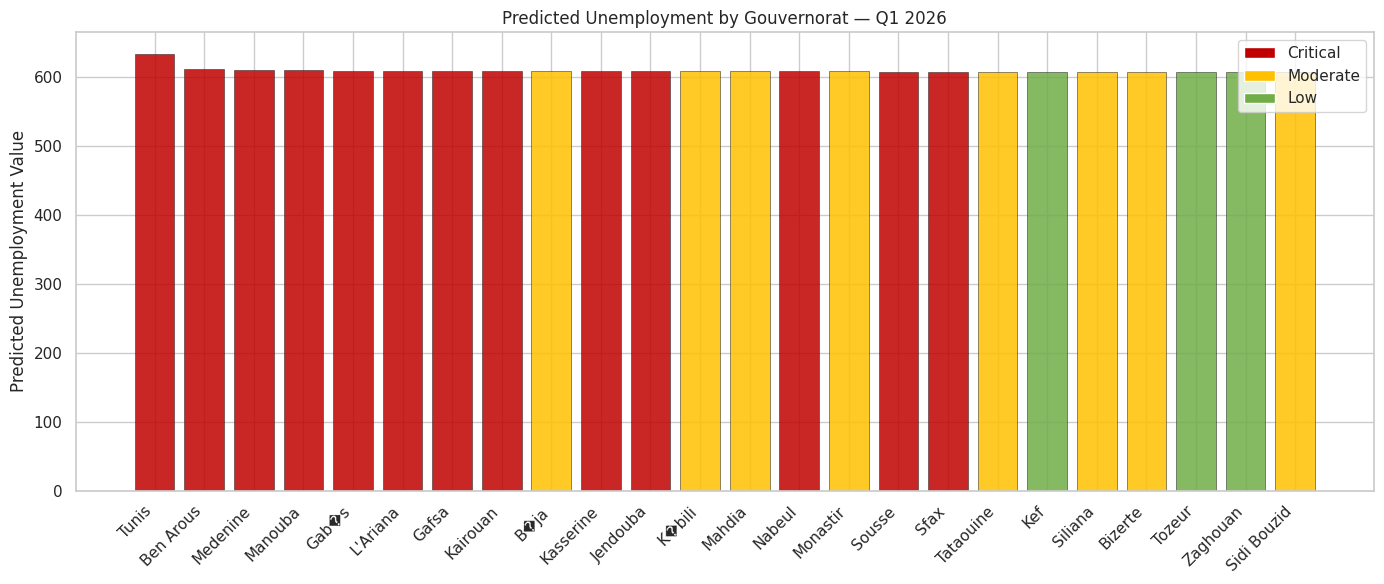

In [ ]:
# Visualize 2026 Forecast by gouvernorat (Q1)
df_q1 = df_forecast[df_forecast['quarter_label']=='Q1-2026'].sort_values('predicted_value', ascending=False)

color_map = {'Low': '#70AD47', 'Moderate': '#FFC000', 'Critical': '#C00000'}
bar_colors = [color_map[r] for r in df_q1['predicted_risk_label']]

plt.figure(figsize=(14, 6))
plt.bar(df_q1['gouvernorat'], df_q1['predicted_value'], color=bar_colors, alpha=0.85, edgecolor='k', linewidth=0.4)
plt.xticks(rotation=45, ha='right')
plt.title('Predicted Unemployment by Gouvernorat — Q1 2026')
plt.ylabel('Predicted Unemployment Value')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C00000', label='Critical'),
                   Patch(facecolor='#FFC000', label='Moderate'),
                   Patch(facecolor='#70AD47', label='Low')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('fig_forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ Section 9 — ChomScore Map (Choropleth Simulation)

In [ ]:
# ============================================================
# ChomScore Summary Table + Interactive Plotly chart
# (Full choropleth needs Tunisia GeoJSON — shown as bar chart here)
# ============================================================

chomscore_df = pd.DataFrame({
    'gouvernorat': chomscore_map.index,
    'chomscore': chomscore_map.values
}).sort_values('chomscore', ascending=False)

chomscore_df['risk'] = chomscore_df['chomscore'].apply(
    lambda x: 'Low Risk' if x >= 66 else ('Moderate Risk' if x >= 33 else 'Critical Risk')
)

fig = px.bar(
    chomscore_df, x='gouvernorat', y='chomscore', color='risk',
    color_discrete_map={'Low Risk':'#70AD47','Moderate Risk':'#FFC000','Critical Risk':'#C00000'},
    title='ChomScore — Employability Index by Gouvernorat (Higher = Better)',
    labels={'chomscore': 'ChomScore (0-100)', 'gouvernorat': 'Gouvernorat'}
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

print('\n=== Final ChomScore Table ===')
print(chomscore_df.to_string(index=False))


=== Final ChomScore Table ===
gouvernorat  chomscore          risk
   Zaghouan      100.0      Low Risk
     Tozeur       99.0      Low Risk
     K�bili       98.2      Low Risk
  Tataouine       96.7      Low Risk
        Kef       96.7      Low Risk
    Siliana       96.3      Low Risk
   Monastir       95.2      Low Risk
       B�ja       93.2      Low Risk
     Mahdia       93.2      Low Risk
Sidi Bouzid       91.7      Low Risk
      Gab�s       90.6      Low Risk
    Bizerte       90.2      Low Risk
   Kairouan       90.2      Low Risk
   Medenine       90.0      Low Risk
   L'Ariana       89.6      Low Risk
   Jendouba       89.4      Low Risk
      Gafsa       88.6      Low Risk
    Manouba       88.6      Low Risk
  Kasserine       88.2      Low Risk
     Sousse       86.3      Low Risk
     Nabeul       84.9      Low Risk
       Sfax       83.7      Low Risk
  Ben Arous       83.4      Low Risk
      Tunis       68.0      Low Risk
   national        0.0 Critical Risk


## ✅ Section 10 — Summary & Conclusions

In [ ]:
print('=' * 60)
print('       TunisChomPredict — Final Summary')
print('=' * 60)

print(f"""
Dataset
  • 4 real sources merged → {df_ml.shape[0]} ML-ready rows
  • 11 features used for training
  • Time period: 2007–2025

Task 1 — Regression (Predict unemployment value)
  • Best model : XGBoost
  • R²         : {r2_score(y_test_reg, preds_best):.4f}
  • MAE        : {mean_absolute_error(y_test_reg, preds_best):.2f}
  • RMSE       : {np.sqrt(mean_squared_error(y_test_reg, preds_best)):.2f}

Task 2 — Classification (Risk category)
  • Best model : XGBoost
  • Accuracy   : {accuracy_score(y_test_clf, preds_clf):.4f}
  • Classes    : Low / Moderate / Critical

Task 3 — Feature Importance
  • Geography (gouvernorat) vs Gender → see Section 7

Task 4 — ChomScore Index
  • Personalized employability score per gouvernorat
  • Range: 0 (worst) → 100 (best)

Task 5 — 2026 Forecast
  • Q1 & Q2 predictions for all 24 gouvernorats
""")

print('=' * 60)
print('  Student: Achref Allegui | Group: GR5 DS')
print('=' * 60)

       TunisChomPredict — Final Summary

Dataset
  • 4 real sources merged → 1618 ML-ready rows
  • 11 features used for training
  • Time period: 2007–2025

Task 1 — Regression (Predict unemployment value)
  • Best model : XGBoost
  • R²         : 0.9945
  • MAE        : 2.60
  • RMSE       : 5.02

Task 2 — Classification (Risk category)
  • Best model : XGBoost
  • Accuracy   : 0.9105
  • Classes    : Low / Moderate / Critical

Task 3 — Feature Importance
  • Geography (gouvernorat) vs Gender → see Section 7

Task 4 — ChomScore Index
  • Personalized employability score per gouvernorat
  • Range: 0 (worst) → 100 (best)

Task 5 — 2026 Forecast
  • Q1 & Q2 predictions for all 24 gouvernorats

  Student: Achref Allegui | Group: GR5 DS


In [ ]:
# ============================================================
# SECTION 11 — Save & Download All Trained Models
# ============================================================
import pickle
import os
import zipfile

# Create models directory
os.makedirs('models', exist_ok=True)

# Save all models
models_to_save = {
    'xgboost_regressor':         best_reg,
    'xgboost_classifier':        best_clf,
    'random_forest_regressor':   reg_models['Random Forest'],
    'random_forest_classifier':  clf_models['Random Forest'],
    'lightgbm_regressor':        reg_models['LightGBM'],
    'lightgbm_classifier':       clf_models['LightGBM'],
    'ridge_regression':          reg_models['Ridge Regression'],
    'logistic_regression':       clf_models['Logistic Regression'],
    'decision_tree_classifier':  clf_models['Decision Tree'],
    'gradient_boosting':         clf_models['Gradient Boosting'],
    'label_encoder_gouvernorat': le_gov,
    'standard_scaler':           scaler,
}

for name, model in models_to_save.items():
    path = f'models/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    size = os.path.getsize(path) / 1024
    print(f'  ✅ {name}.pkl  ({size:.1f} KB)')

# Zip everything
zip_path = 'TunisChomPredict_models.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for name in models_to_save:
        zf.write(f'models/{name}.pkl')
    # Also save chomscore table
    chomscore_df.to_csv('models/chomscore_table.csv', index=False)
    zf.write('models/chomscore_table.csv')

print(f'\n📦 All models zipped → {zip_path}')
print(f'   Total zip size: {os.path.getsize(zip_path)/1024:.1f} KB')

# Download (Colab only)
from google.colab import files
files.download(zip_path)

  ✅ xgboost_regressor.pkl  (381.6 KB)
  ✅ xgboost_classifier.pkl  (1109.5 KB)
  ✅ random_forest_regressor.pkl  (2991.4 KB)
  ✅ random_forest_classifier.pkl  (3639.2 KB)
  ✅ lightgbm_regressor.pkl  (248.2 KB)
  ✅ lightgbm_classifier.pkl  (1350.0 KB)
  ✅ ridge_regression.pkl  (0.5 KB)
  ✅ logistic_regression.pkl  (1.0 KB)
  ✅ decision_tree_classifier.pkl  (8.5 KB)
  ✅ gradient_boosting.pkl  (775.0 KB)
  ✅ label_encoder_gouvernorat.pkl  (0.5 KB)
  ✅ standard_scaler.pkl  (1.0 KB)

📦 All models zipped → TunisChomPredict_models.zip
   Total zip size: 2512.0 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>